In [1]:
import torch
from torchvision import models, transforms
import torch.nn as nn
import os
from PIL import Image
from torch.utils.data import Dataset






In [2]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=66af235a0c3a380f013e05dfe162fedeb68291309fe6d25a8844167b4f8cad2a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
from torchvision import models
def get_model():
    """Load ResNet18 with a single output neuron for Binary Classification."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

In [4]:
def load_model_from_pth(checkpoint_path, device):
    """
    Loads the ResNet18 model from a standard PyTorch .pth state_dict.
    """
    model = get_model()
    # map_location ensures it loads on CPU if GPU is not available
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pth: {checkpoint_path}")
    return model

def load_model_from_pkl(checkpoint_path, device):
    """
    Loads the ResNet18 model from a Flower .pkl checkpoint (list of NumPy arrays).
    """
    model = get_model()

    # Load the list of numpy arrays
    with open(checkpoint_path, "rb") as f:
        ndarrays = pickle.load(f)

    # Map the numpy arrays to the model's state_dict keys
    params_dict = zip(model.state_dict().keys(), ndarrays)
    state_dict = OrderedDict({k: torch.tensor(v, dtype=torch.float32) for k, v in params_dict})

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pkl: {checkpoint_path}")
    return model

In [5]:
from google.colab import drive
drive.mount('/content/drive')
PATH="/content/drive/MyDrive/AITDM/"
TEST_PATH="/content/val/"

Mounted at /content/drive


In [6]:
!unzip -o  /content/drive/MyDrive/AITDM/covid_val.zip -d /content

Streaming output truncated to the last 5000 lines.
  inflating: /content/val/86746808-b97b-4a47-b073-973fa4babd3f.jpg  
  inflating: /content/val/868aa791-fca9-4915-b8e2-c38460d90426.jpg  
  inflating: /content/val/8697ce4a-d16c-44f4-9271-393000aa9d42.jpg  
  inflating: /content/val/8698df10-24b5-4b01-ab93-373ba59e26ba.jpg  
  inflating: /content/val/869e160d-9d79-42dc-beab-04bd3607862a.jpg  
  inflating: /content/val/869facf4-a6d0-452b-b001-c7ca04524955.jpg  
  inflating: /content/val/86a95eba-c600-4016-8e14-febf0dff0653.jpg  
  inflating: /content/val/86ad951a-d0b6-4af7-b303-dd94c1dce684.jpg  
  inflating: /content/val/86b194b5-dc85-47a9-b77c-e17f68d6d5c9.jpg  
  inflating: /content/val/86b32de2-c74f-4446-9541-9a27e1021984.jpg  
  inflating: /content/val/86b4fe0b-3545-4b94-abcf-7710922257ce.jpg  
  inflating: /content/val/86bd39a4-568d-443c-9ad4-4c9807d7f136.jpg  
  inflating: /content/val/86c14816-f11b-4663-badd-50b8a6abded9.jpg  
  inflating: /content/val/86c27916-8e16-46f3-bfc3-41

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model=load_model_from_pth(PATH + "resnet_fedavg/global_model_final.pth", device)

cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 103MB/s]


✅ Model loaded from .pth: /content/drive/MyDrive/AITDM/resnet_fedavg/global_model_final.pth


In [8]:
class CovidDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        if os.path.exists(img_path):
            image = Image.open(img_path).convert('RGB')
        else:
            # This is a safety net; if this triggers, the model won't learn.
            image = Image.new('RGB', (256, 256))
            print("Failure!!!")

        if self.transform:
            image = self.transform(image)

        # Ensure label is read correctly from "positive"/"negative"
        label_str = str(self.df.iloc[idx]['label']).lower()
        label = torch.tensor([1.0 if label_str == "positive" else 0.0], dtype=torch.float32)
        return image, label, img_name, img_path

In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
print(f"Processing images on: {device}")

Processing images on: cpu


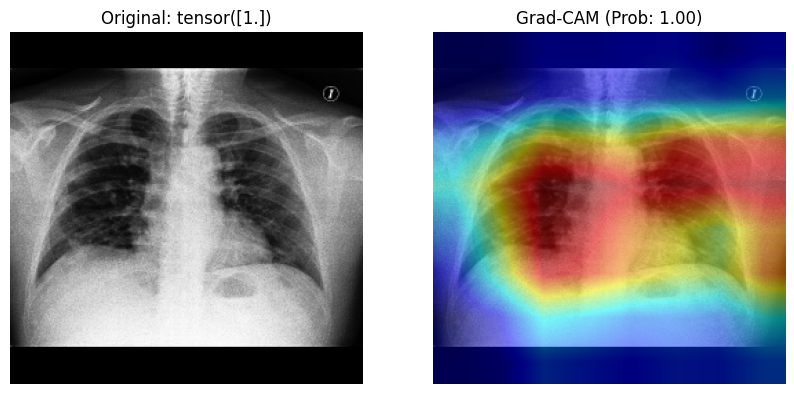

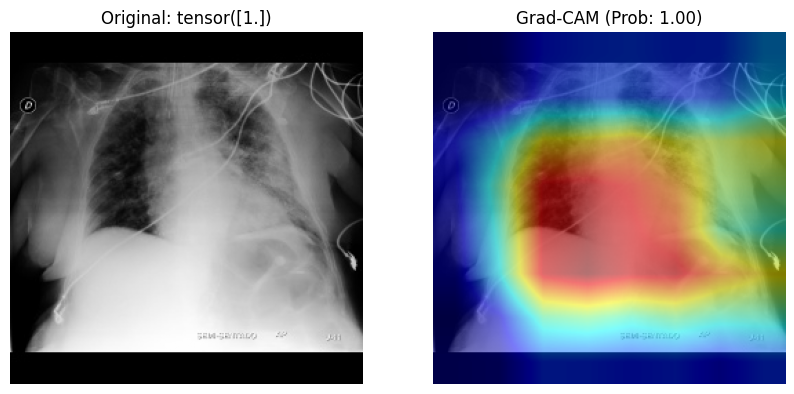

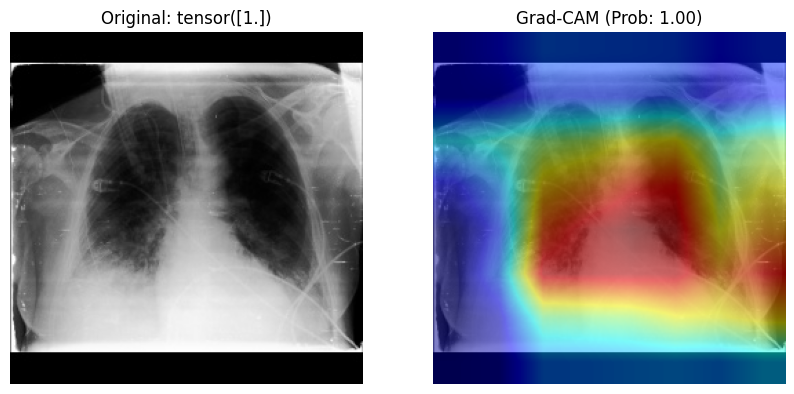

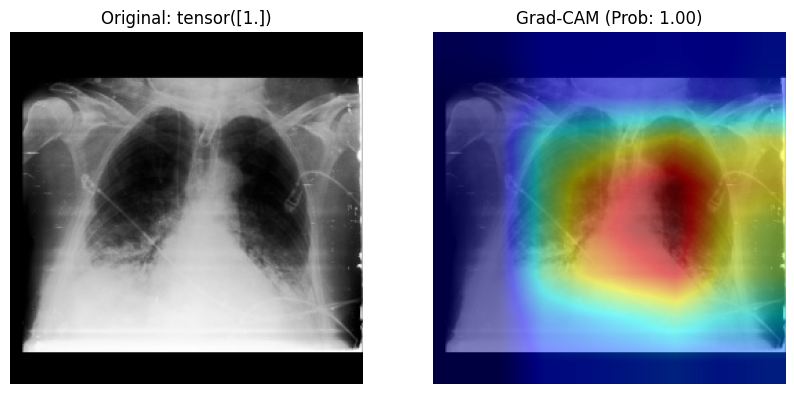

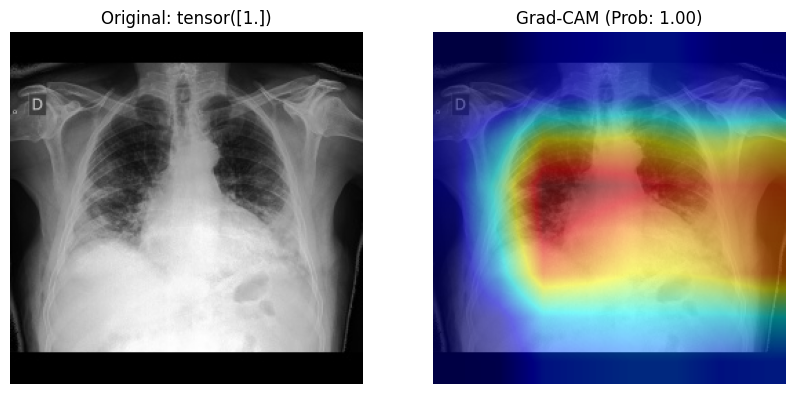

In [10]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- GRAD-CAM IMPORTS ---

test_df  = pd.read_csv(PATH  + "val.txt",  sep=" ", header=None, index_col=False, names=["patient_id", "filename", "label", "source"])

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = CovidDataset(test_df, img_dir=TEST_PATH, transform=transform)
for i in range(len(dataset)):
  if i==5:
    break
  image, label, image_name, img_path = dataset[i]
  raw_image = Image.open(img_path).convert('RGB')
  input_batch = image.unsqueeze(0).to(device)
  output = model(input_batch)
  prob = torch.sigmoid(output).item()
  predicted = 1 if prob > 0.5 else 0
  targets = [ClassifierOutputTarget(0)]
  # Generate the grayscale cam mask
  grayscale_cam = cam(input_tensor=input_batch, targets=targets)
  grayscale_cam = grayscale_cam[0, :] # Take first item in batch
# --- Visualization ---
    # Prepare image for overlay (Must be float32 in range [0, 1])
  rgb_img = np.array(raw_image).astype(np.float32) / 255.0

    # Resize raw image if it doesn't match the transform size (256x256)
    # This ensures the heatmap lines up perfectly
  rgb_img = cv2.resize(rgb_img, (256, 256))

  visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
  # --- Plotting/Saving ---
  #
  plt.figure(figsize=(10, 5))

  # Original
  plt.subplot(1, 2, 1)
  plt.imshow(rgb_img)
  plt.title(f"Original: {label}")
  plt.axis("off")

  # Grad-CAM
  plt.subplot(1, 2, 2)
  plt.imshow(visualization)
  plt.title(f"Grad-CAM (Prob: {prob:.2f})")
  plt.axis("off")

  plt.show()
  # plt.savefig(f"gradcam_{file_name}") # Uncomment to save
  plt.close()
  if(predicted == 0):
    if(predicted == label.item()):
      print("Correct")
    else:
      print("Incorrect")
      print(f"{predicted} vs {label.item()}")


